# 05. ELECTRE TRI-B 시범모형

## 1. 목적과 해석 범위
동일한 g1~g4와 b1·b2에서 고정 단순규칙과 세 ELECTRE 시나리오를 비교한다. 점검단계는 확인 순서이며 위기·지원대상·미래확률이 아니다. 자료가 보여주는 값, 모형 규칙이 부여한 단계, 현재 자료로 판단할 수 없는 원인·정책효과를 구분한다.

In [1]:
from pathlib import Path
import json, sys
import pandas as pd
from IPython.display import display, Image
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))
from model import config, manifest
run_manifest = manifest.load_manifest(ROOT)
assert run_manifest and run_manifest['run_mode'] == 'SCENARIO_REGISTERED'
def current(key):
    table = manifest.load_current_table(ROOT, key)
    assert table is not None, f'{key} is not CURRENT'
    return table


## 2. 입력자료·파라미터·실행 manifest

In [2]:
registry = current('electre_parameter_registry')
display(pd.DataFrame([{k: run_manifest[k] for k in ['run_id','run_started_at','run_mode','parameter_set_id','input_sha256','model_spec_version']}]))
display(registry.drop_duplicates('scenario_id'))


,run_id,run_started_at,run_mode,parameter_set_id,input_sha256,model_spec_version
0,20260916T061849980743Z-d1794cbf,2026-09-16T06:18:49.980743+00:00,SCENARIO_REGISTERED,changwon-electre-pilot-v1,58499908a6af50344a1362c55c840a58cfd80d4373c709...,changwon-transition-diagnosis-model/1.0.0


,scenario_id,weight_g1,weight_g2,weight_g3,weight_g4,b1_g1,b1_g2,b1_g3,b1_g4,b2_g1,...,administratively_approved,run_id,run_started_at,input_sha256,input_sha256_raw_bytes,model_spec_version,parameter_set_id,parameter_status,effective_parameter_status,parameter_file_sha256
0,기준,0.2,0.2,0.3,0.3,100,2.0,5.0,2,500,...,False,20260916T061849980743Z-d1794cbf,2026-09-16T06:18:49.980743+00:00,58499908a6af50344a1362c55c840a58cfd80d4373c709...,9eab0a418a59d45db45d451cd60b05233a7a4f1c756a49...,changwon-transition-diagnosis-model/1.0.0,changwon-electre-pilot-v1,SCENARIO_REGISTERED,SCENARIO_REGISTERED,bef58985e0714e5a149bbbbf667ed271296f86fc1b7d05...
1,고용중시,0.3,0.3,0.2,0.2,100,2.0,5.0,2,500,...,False,20260916T061849980743Z-d1794cbf,2026-09-16T06:18:49.980743+00:00,58499908a6af50344a1362c55c840a58cfd80d4373c709...,9eab0a418a59d45db45d451cd60b05233a7a4f1c756a49...,changwon-transition-diagnosis-model/1.0.0,changwon-electre-pilot-v1,SCENARIO_REGISTERED,SCENARIO_REGISTERED,bef58985e0714e5a149bbbbf667ed271296f86fc1b7d05...
2,지속성중시,0.2,0.2,0.2,0.4,100,2.0,5.0,2,500,...,False,20260916T061849980743Z-d1794cbf,2026-09-16T06:18:49.980743+00:00,58499908a6af50344a1362c55c840a58cfd80d4373c709...,9eab0a418a59d45db45d451cd60b05233a7a4f1c756a49...,changwon-transition-diagnosis-model/1.0.0,changwon-electre-pilot-v1,SCENARIO_REGISTERED,SCENARIO_REGISTERED,bef58985e0714e5a149bbbbf667ed271296f86fc1b7d05...


## 3. 단순 규칙 정의
각 경계에서 네 기준 중 2개 이상을 충족하고, 그중 g1·g2·g4 고용근거가 하나 이상일 때 통과한다. b2부터 확인하며 결측은 `UNDETERMINED`이다.

## 4. ELECTRE 계산 구조
q=p=0이므로 부분 concordance는 경계 이상 1, 미만 0이다. 종합 concordance는 가중 기여도 합이며 lambda 이상과 고용증거 게이트를 모두 충족해야 outrank한다.

## 5. 세 시나리오 파라미터

In [3]:
display(registry[['scenario_id','weight_g1','weight_g2','weight_g3','weight_g4','lambda','delta_emp','require_employment_evidence','parameter_status','administratively_approved']])


,scenario_id,weight_g1,weight_g2,weight_g3,weight_g4,lambda,delta_emp,require_employment_evidence,parameter_status,administratively_approved
0,기준,0.2,0.2,0.3,0.3,0.5,0.0,True,SCENARIO_REGISTERED,False
1,고용중시,0.3,0.3,0.2,0.2,0.6,0.0,True,SCENARIO_REGISTERED,False
2,지속성중시,0.2,0.2,0.2,0.4,0.6,0.0,True,SCENARIO_REGISTERED,False


## 6. 최신분기 분류 결과

,industry,scenario_id,electre_stage,concordance_b1,concordance_b2,routeability_status
0,기계,기준,PRIORITY,1.0,0.7,SINGLE_INDUSTRY_CATEGORY
1,기타,기준,OBSERVE,0.0,0.0,REQUIRES_DISAGGREGATION
2,목재종이,기준,PRIORITY,0.8,0.5,SINGLE_INDUSTRY_CATEGORY
3,비금속,기준,OBSERVE,0.3,0.3,SINGLE_INDUSTRY_CATEGORY
4,석유화학,기준,OBSERVE,0.3,0.0,SINGLE_INDUSTRY_CATEGORY
5,섬유의복,기준,OBSERVE,0.3,0.3,SINGLE_INDUSTRY_CATEGORY
6,운송장비,기준,CHECK,0.5,0.3,SINGLE_INDUSTRY_CATEGORY
7,음식료,기준,CHECK,0.5,0.3,SINGLE_INDUSTRY_CATEGORY
8,전기전자,기준,CHECK,0.5,0.3,SINGLE_INDUSTRY_CATEGORY
9,철강,기준,CHECK,0.5,0.3,SINGLE_INDUSTRY_CATEGORY


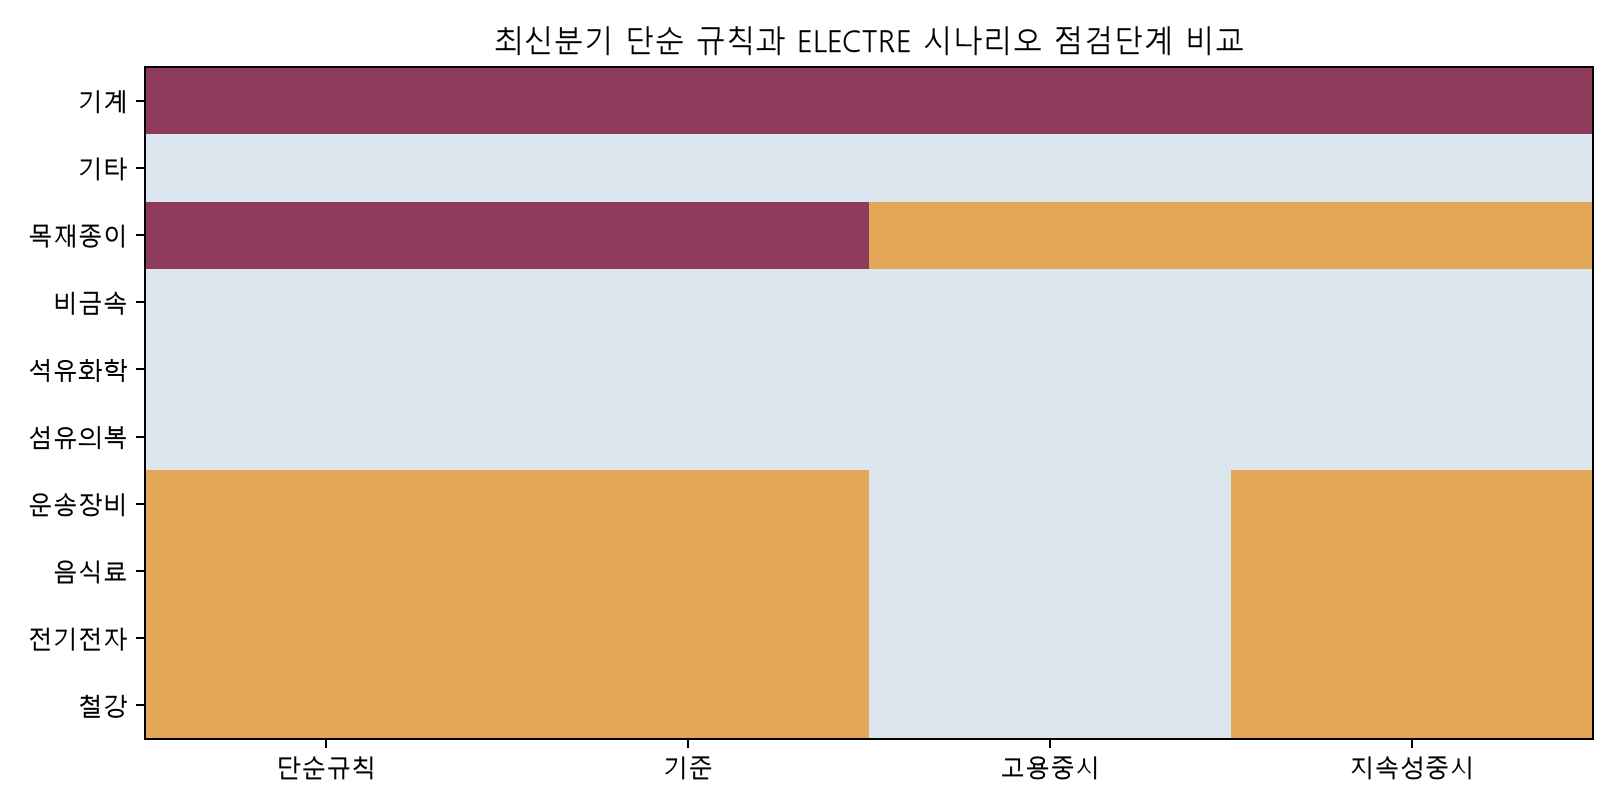

In [4]:
latest = current('electre_latest_classification')
rule_latest = current('simple_rule_latest')
display(latest[['industry','scenario_id','electre_stage','concordance_b1','concordance_b2','routeability_status']])
display(Image(filename=str(ROOT/'outputs/figures/electre_latest_stage_comparison.png')))


## 7. 단순 규칙과 ELECTRE 비교
## 8. 불일치 사례 설명

,count,mean
scenario_id,,
고용중시,180,0.777778
기준,180,0.983333
지속성중시,180,0.950000


,scenario_id,industry,quarter,simple_rule_stage,electre_stage,disagreement_boundary,disagreement_drivers,disagreement_explanation
0,기준,기계,2022Q1,CHECK,OBSERVE,b1,"b1:g1(w=0.20),g2(w=0.20)",b1: 단순규칙은 2개 기준으로 통과했으나 가중합 0.40가 lambda 0.50 미만
120,기준,운송장비,2025Q1,CHECK,OBSERVE,b1,"b1:g1(w=0.20),g2(w=0.20)",b1: 단순규칙은 2개 기준으로 통과했으나 가중합 0.40가 lambda 0.50 미만
156,기준,전기전자,2025Q1,CHECK,OBSERVE,b1,"b1:g1(w=0.20),g2(w=0.20)",b1: 단순규칙은 2개 기준으로 통과했으나 가중합 0.40가 lambda 0.50 미만
183,고용중시,기계,2022Q4,PRIORITY,CHECK,b2,"b2:g1(w=0.30),g4(w=0.20)",b2: 단순규칙은 2개 기준으로 통과했으나 가중합 0.50가 lambda 0.60 미만
188,고용중시,기계,2024Q1,CHECK,OBSERVE,b1,"b1:g1(w=0.30),g4(w=0.20)",b1: 단순규칙은 2개 기준으로 통과했으나 가중합 0.50가 lambda 0.60 미만
196,고용중시,기계,2026Q1,CHECK,OBSERVE,b1,"b1:g1(w=0.30),g3(w=0.20)",b1: 단순규칙은 2개 기준으로 통과했으나 가중합 0.50가 lambda 0.60 미만
199,고용중시,기타,2022Q2,CHECK,OBSERVE,b1,"b1:g3(w=0.20),g4(w=0.20)",b1: 단순규칙은 2개 기준으로 통과했으나 가중합 0.40가 lambda 0.60 미만
211,고용중시,기타,2025Q2,CHECK,OBSERVE,b1,"b1:g2(w=0.30),g4(w=0.20)",b1: 단순규칙은 2개 기준으로 통과했으나 가중합 0.50가 lambda 0.60 미만
212,고용중시,기타,2025Q3,CHECK,OBSERVE,b1,"b1:g2(w=0.30),g4(w=0.20)",b1: 단순규칙은 2개 기준으로 통과했으나 가중합 0.50가 lambda 0.60 미만
213,고용중시,기타,2025Q4,PRIORITY,OBSERVE,b1|b2,"b1:g2(w=0.30),g4(w=0.20); b2:g2(w=0.30),g4(w=0...",b1: 단순규칙은 2개 기준으로 통과했으나 가중합 0.50가 lambda 0.60 ...


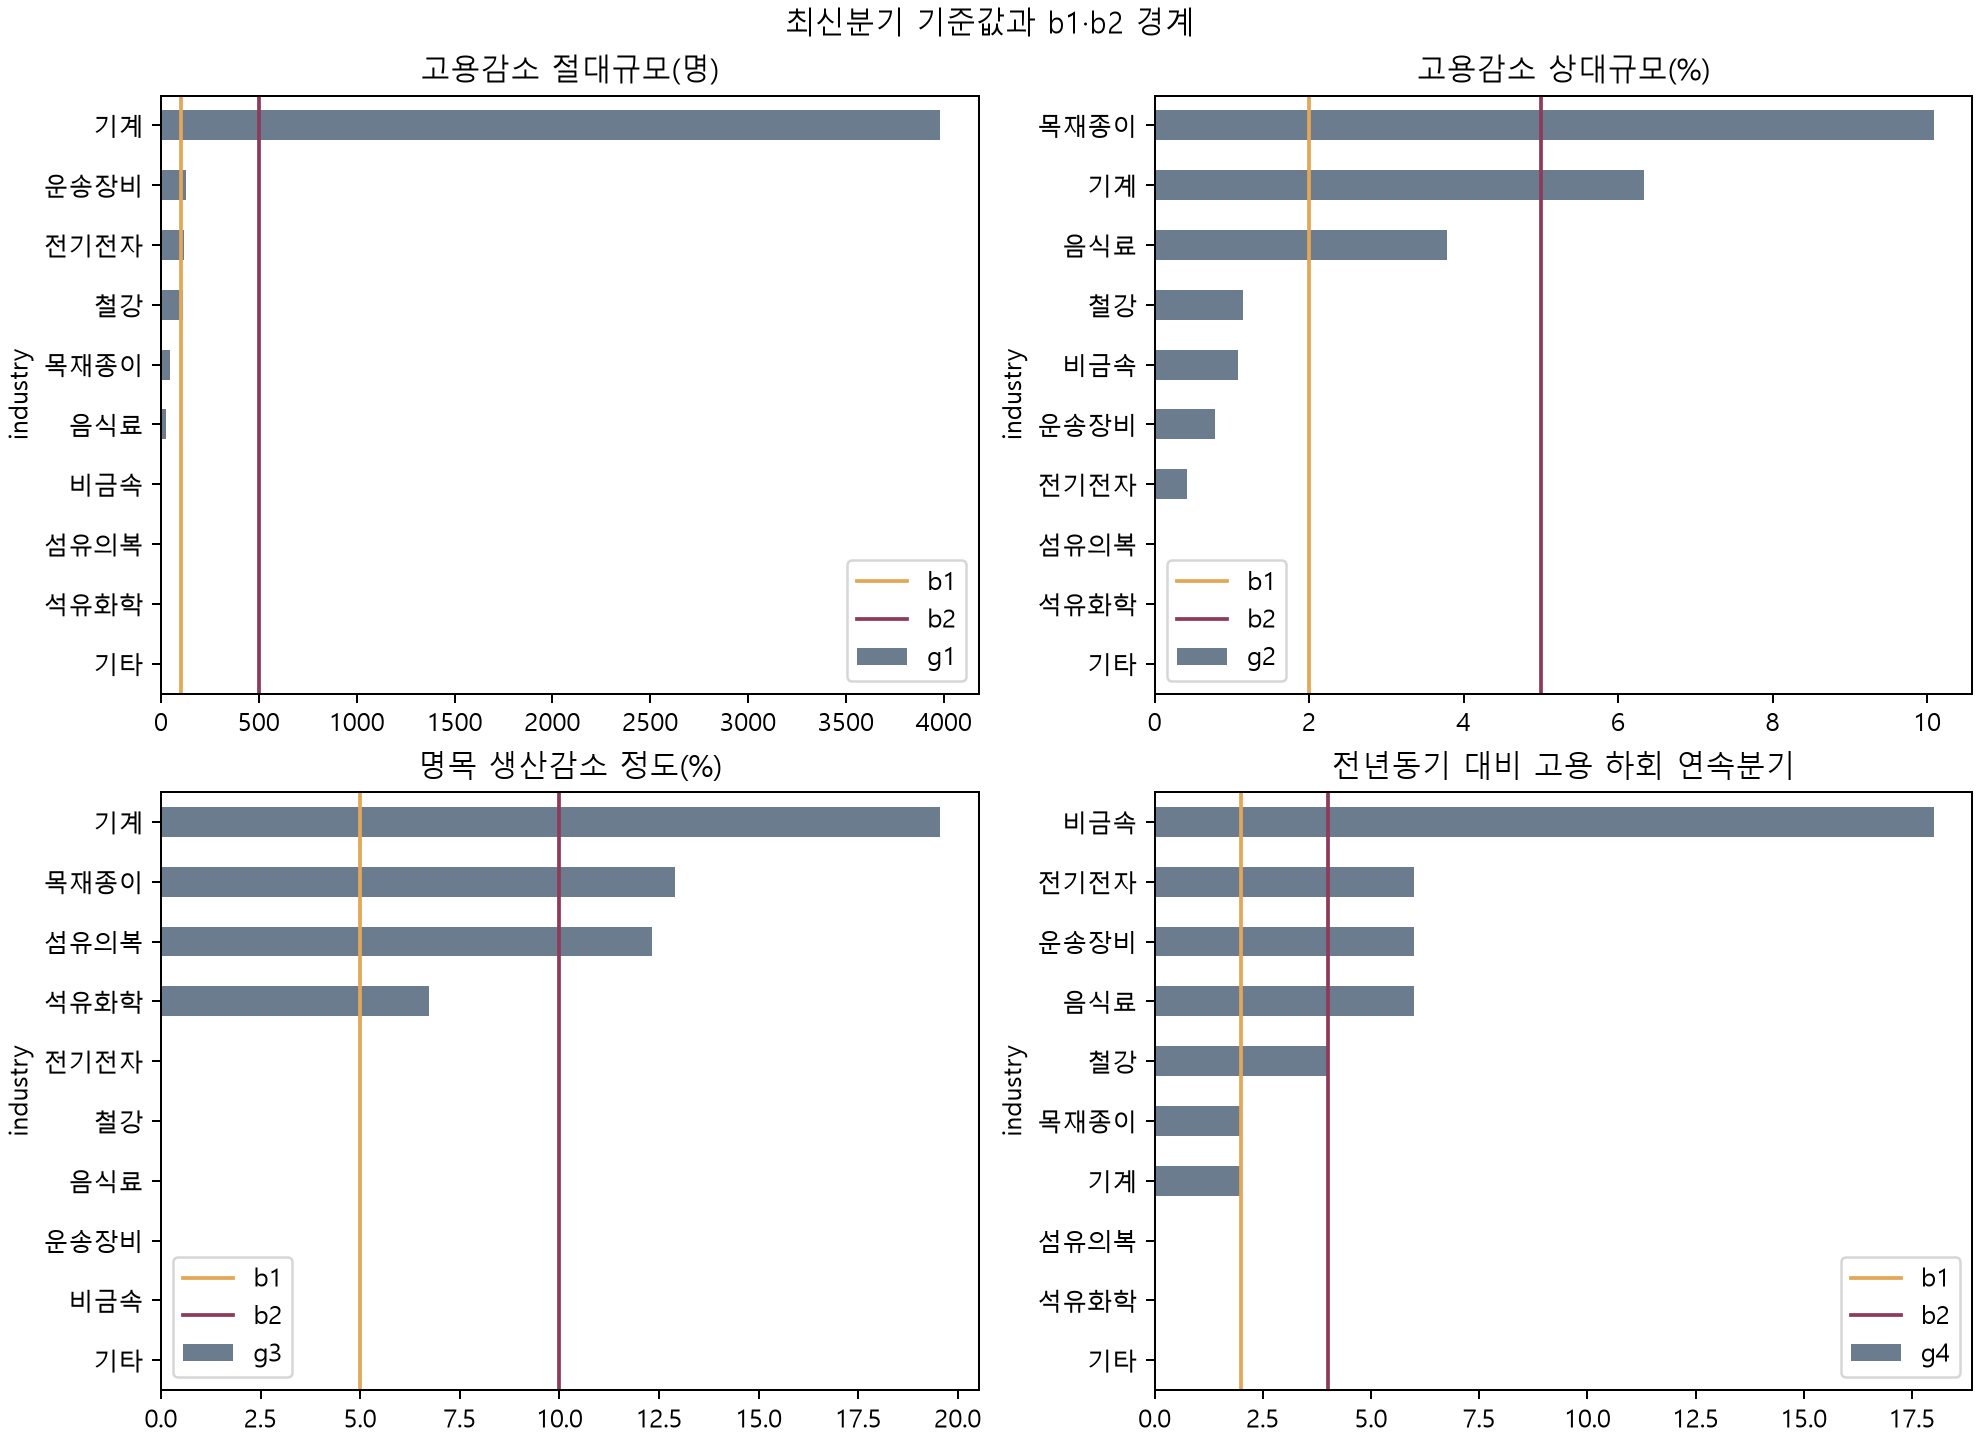

In [5]:
comparison = current('electre_vs_rule_comparison')
display(comparison.groupby('scenario_id')['stage_agrees'].agg(['count','mean']))
display(comparison.loc[~comparison.stage_agrees.astype(bool), ['scenario_id','industry','quarter','simple_rule_stage','electre_stage','disagreement_boundary','disagreement_drivers','disagreement_explanation']].head(20))
display(Image(filename=str(ROOT/'outputs/figures/electre_latest_criteria_boundaries.png')))


## 9. 기준 제거 민감도

count  \
scenario_id removal_method                               removed_criterion          
고용중시        criterion_removed_weights_renormalized       g1                   160   
                                                         g2                   160   
                                                         g3                   160   
                                                         g4                   160   
            criterion_support_removed_no_renormalization g1                   160   
                                                         g2                   160   
                                                         g3                   160   
                                                         g4                   160   
기준          criterion_removed_weights_renormalized       g1                   160   
                                                         g2                   160   
                                                         g3                   160   
                                                         g4                   160   
            criterion_support_removed_no_renormalization g1                   160   
                                                         g2                   160   
                                                         g3                   160   
                                                         g4                   160   
지속성중시       criterion_removed_weights_renormalized       g1                   160   
                                                         g2                   160   
                                                         g3                   160   
                                                         g4                   160   
            criterion_support_removed_no_renormalization g1                   160   
                                                         g2                   160   
                                                         g3                   160   
                                                         g4                   160   

                                                                            sum  \
scenario_id removal_method                               removed_criterion        
고용중시        criterion_removed_weights_renormalized       g1                  33   
                                                         g2                  30   
                                                         g3                  32   
                                                         g4                   6   
            criterion_support_removed_no_renormalization g1                  19   
                                                         g2                  36   
                                                         g3                  19   
                                                         g4                  19   
기준          criterion_removed_weights_renormalized       g1                   9   
                                                         g2                  29   
                                                         g3                  11   
                                                         g4                  37   
            criterion_support_removed_no_renormalization g1                   9   
                                                         g2                  29   
                                                         g3                  11   
                                                         g4                  44   
지속성중시       criterion_removed_weights_renormalized       g1                  11   
                                                         g2                  27   
                                                         g3                   5   
                                                         g4                  43   
            criterion_support_removed_n

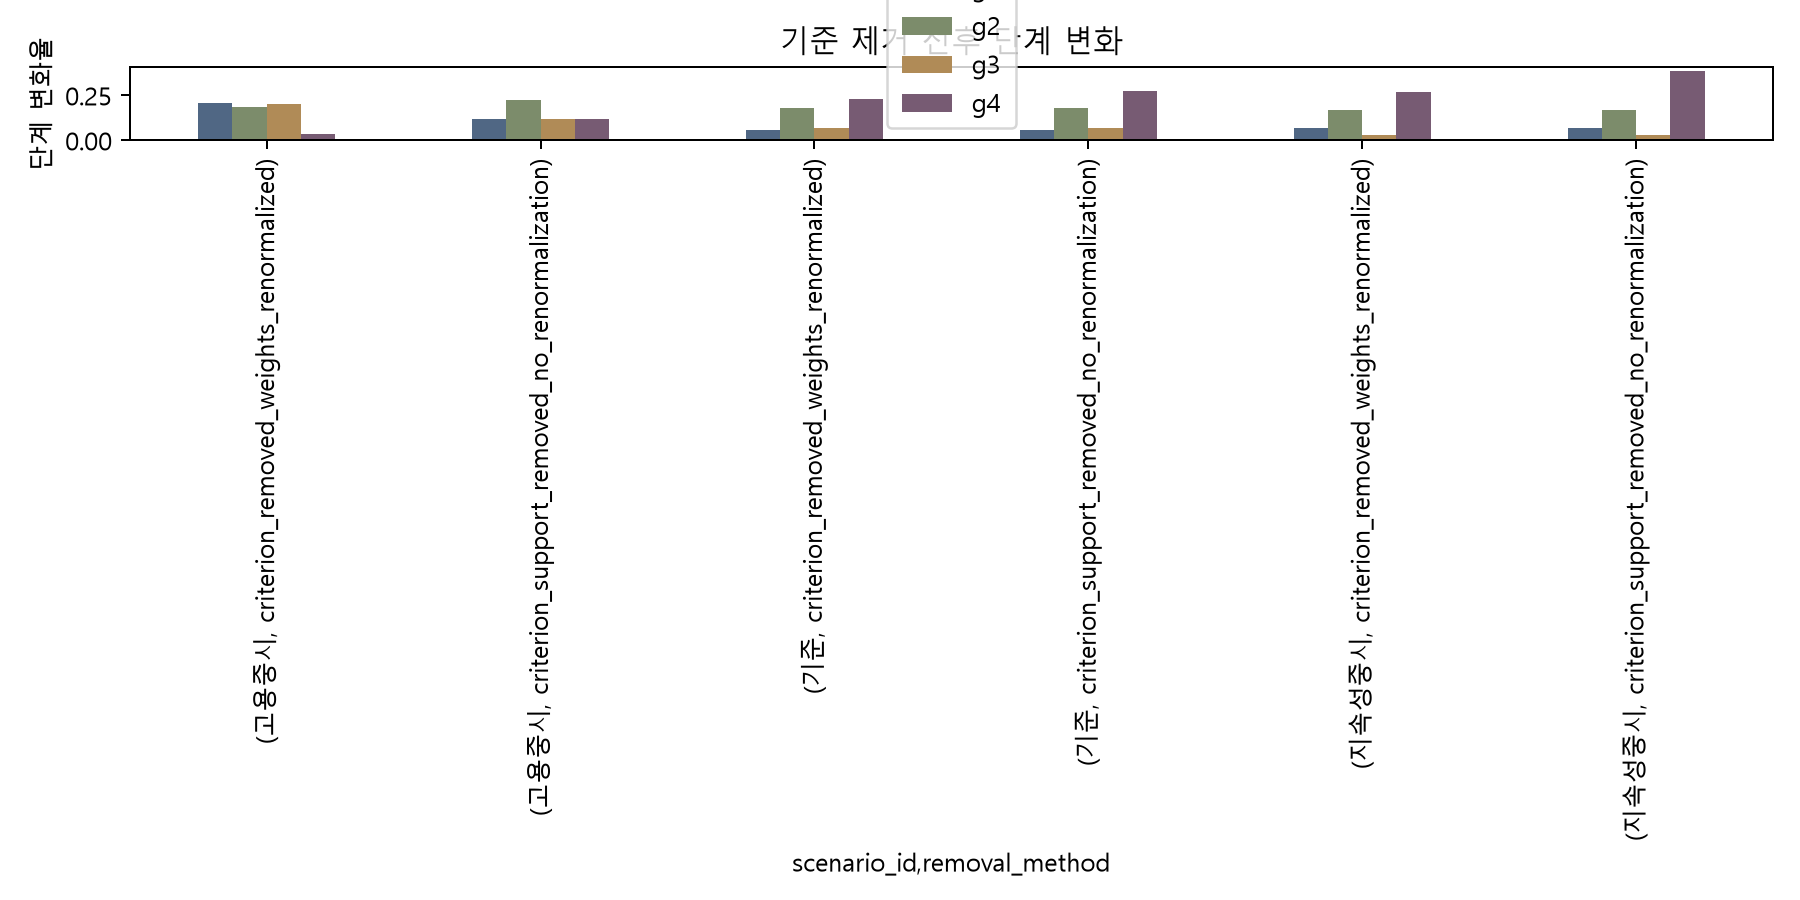

In [6]:
loo = current('electre_leave_one_criterion_out')
complete = loo[loo.base_stage != 'UNDETERMINED']
display(complete.groupby(['scenario_id','removal_method','removed_criterion']).changed.agg(['count','sum','mean']))
display(Image(filename=str(ROOT/'outputs/figures/electre_leave_one_out_changes.png')))


## 10. 단조성·dominance 검증

In [7]:
mono = current('electre_monotonicity_test')
dom = current('electre_dominance_test')
display(mono.groupby('scenario_id')[['n_cases','n_violations']].sum())
display(dom[['scenario_id','test_scope','n_comparisons','n_violations','passed']])
assert mono.n_violations.sum() == 0 and dom.n_violations.sum() == 0


,n_cases,n_violations
scenario_id,,
고용중시,33,0
기준,33,0
지속성중시,33,0


,scenario_id,test_scope,n_comparisons,n_violations,passed
0,기준,SYNTHETIC,65,0,True
1,기준,ACTUAL_COMPLETE_CASE,7133,0,True
2,고용중시,SYNTHETIC,65,0,True
3,고용중시,ACTUAL_COMPLETE_CASE,7133,0,True
4,지속성중시,SYNTHETIC,65,0,True
5,지속성중시,ACTUAL_COMPLETE_CASE,7133,0,True


## 11. 품질 플래그와 판정불가
threshold 민감, PPI 부호 불안정, N/INVALID, g4 절단, 소규모 업체, 기타 업종 라우팅은 점검단계와 별도 열이다. `기타`는 수치 계산과 별개로 `REQUIRES_DISAGGREGATION`을 유지한다.

## 12. ELECTRE가 추가한 정보
ELECTRE는 기준별 중요도를 concordance 기여도로 드러내며, 동일한 통과 기준 수라도 어떤 기준 조합인지에 따라 구분한다. 실제 추가 가치는 아래 불일치율과 기준제거 민감도를 함께 보고 판단한다.

## 13. 설명하기 어려운 결과
경계 바로 전후와 가중합이 lambda에 정확히 닿는 조합은 규칙 설명이 필요하다. 불일치 표의 실제 값·가중치·경계를 근거로 설명하며 원인을 추정하지 않는다.

## 14. 채택 여부 판단을 위한 사람의 확인사항
행정 담당자는 불일치 사례의 한 문장 설명 가능성, lambda=0.50 조합의 정책 의미, 기준 제거 의존도, 20개 판정불가와 `기타` 라우팅을 확인해야 한다. 본 노트북은 행정 승인을 부여하거나 공식 단일 등급을 만들지 않는다.